In [1]:
import quimb as qu
import quimb.tensor as qtn
import numpy as np
import re
print('done')

c:\Users\titou\miniforge3\envs\projetqte\Lib\site-packages\cotengra\hyperoptimizers\hyper.py:39: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(


done


In [2]:
R0 = Node(index='R0',up = None,up_bdim = 0,childrens=['R0A1','R0B1'],childrens_bdim = [2,2])
R0A1 = Node(index='R0A1',up = 'R0',up_bdim = 2,childrens=['R0A2'],childrens_bdim = [2])
# R0A2 = Node(index='R0A2',up = 'R0A1',up_bdim = 2,childrens=[],childrens_bdim = [])
# R0B1 = Node(index='R0B1',up = 'R0',up_bdim = 2,childrens=['R0B1A1','R0B1B1'],childrens_bdim = [2,2])
# R0B1A1 = Node(index='R0B1A1',up = 'R0B1',up_bdim = 2,childrens=[],childrens_bdim = [2])
# R0B1B1 = Node(index='R0B1B1',up = 'R0B1',up_bdim = 2,childrens=[],childrens_bdim = [2])

Tree2 = Tree()
Tree2.add(R0)
Tree2.add(R0A1)
Tree2.draw()
# Tree2.network.delete('R0A1')

i = 'R0A1'
j = 'R0'

node_1 = Tree2.nodes[i]
node_2 = Tree2.nodes[j]

side_1 = list(node_1.tensor.inds)
side_2 = list(node_2.tensor.inds)
bond_ind = (set(node_1.tensor.inds) & set(node_2.tensor.inds)).pop()
side_1.remove(bond_ind)
side_2.remove(bond_ind)

node_1.reindex({'out'+i:'old_out'+i})
node_2.reindex({'out'+j:'old_out'+j})

gate = qtn.Tensor(data=np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]],dtype=float).reshape(2,2,2,2),
                    inds = ['old_out'+i,'old_out'+j,'out'+i,'out'+j],tags = ['swap'])

contracted_qubits = node_1.tensor @ node_2.tensor
contracted_qubits_and_gate = contracted_qubits @ gate

split_tensor = contracted_qubits_and_gate.split(left_inds=side_1,right_inds=side_2,method='svd',absorb='right',bond_ind=bond_ind)

ind_1 = split_tensor.ind_map[side_1[0]].pop()
tensor_1 = split_tensor.tensor_map[ind_1]
ind_2 = split_tensor.ind_map[side_2[0]].pop()
tensor_2 = split_tensor.tensor_map[ind_2]

tensor_1.drop_tags(list(gate.tags)+[j])
tensor_2.drop_tags(list(gate.tags)+[i])

result = tensor_1 & tensor_2
node_1.tensor = tensor_1
node_2.tensor = tensor_2

Tree2.network.delete(i)
Tree2.network.delete(j)

Tree2.add(node_1)
Tree2.add(node_2)
Tree2.draw()



NameError: name 'Node' is not defined

In [48]:
class Tree:
    def __init__(self,root):
        self.nodes = {}
        self.network = None
        self.neutral = root
        self.root = root

        self.nodes[root.index] = root
        self.network = root.tensor

        ####### utile dans les autres fonc
    def to_str(self,node):
        return ''.join(node)

    def to_list(self,node):
        return re.findall(r'[A-Za-z]|\d+', node)

    def diff_part_str(self,A,B):
        A = self.to_list(A)
        B = self.to_list(B)

        prefix = []

        for i in range(min(len(A),len(B))):
            if A[i] == B[i]:
                prefix.append(A[i])
            else:
                break

        if not(prefix[-1].isnumeric()):
            prefix.pop()
        return prefix,A[len(prefix):],B[len(prefix):]

    def get_previous_node(self,node):
        nb = int(node[-1])
        if nb == 1:
            return node[0:-2]
        else:
            return node[0:-1]+[str(nb-1)]

    # def is_adjacent(self,i,j):
    #     if get_previous_node(i) == j or get_previous_node(j) == i:
    #         return True
    #     else:
    #         return False

    def get_path_to_last_common_node(self,node,last_common_node):

        path = []
        
        previous_node = node
        while previous_node != last_common_node:
            path.append(self.to_str(previous_node))
            previous_node = self.get_previous_node(previous_node)

        path.append(self.to_str(last_common_node))
        return path

    def get_path(self,A,B):
        last_common_node,tail_A,tail_B = self.diff_part_str(A,B)

        A_to_lcn = list(reversed(self.get_path_to_last_common_node(self.to_list(A),last_common_node)))
        B_to_lcn = list(reversed(self.get_path_to_last_common_node(self.to_list(B),last_common_node)))


        for i in range(min(len(A_to_lcn),len(B_to_lcn))):
            if A_to_lcn[i] != B_to_lcn[i]:
                return list(reversed(A_to_lcn[i-1:]))+B_to_lcn[i:]
        return list(reversed(A_to_lcn[i+1:]))+B_to_lcn[i:]

    def swap_adjacent(self,i,j):
        array = np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]],dtype=float).reshape(2,2,2,2)
        self.apply_gate(i,j,gate_array = array)

    
    ###### methodes

    def shift_neutral(self,i,j,side = 'right'):
        # if not(self.is_adjacent(i,j)):
        #     raise Exception('not adjacent')
        
        # get nodes
        node_1 = self.nodes[i]
        node_2 = self.nodes[j]
        # get indexes
        side_1 = list(node_1.tensor.inds)
        side_2 = list(node_2.tensor.inds)
        bond_ind = (set(node_1.tensor.inds) & set(node_2.tensor.inds)).pop()
        side_1.remove(bond_ind)
        side_2.remove(bond_ind)

        # 'apply' gate
        contracted_qubits = node_1.tensor @ node_2.tensor

        split_tensor = contracted_qubits.split(left_inds=side_1,right_inds=side_2,method='svd',absorb=side,bond_ind=bond_ind)
        
        ind_1 = split_tensor.ind_map[side_1[0]].pop()
        tensor_1 = split_tensor.tensor_map[ind_1]
        ind_2 = split_tensor.ind_map[side_2[0]].pop()
        tensor_2 = split_tensor.tensor_map[ind_2]

        tensor_1.drop_tags([j])
        tensor_2.drop_tags([i])

        result = tensor_1 & tensor_2
        node_1.tensor = tensor_1
        node_2.tensor = tensor_2

        self.network.delete(i)
        self.network.delete(j)

        self.network = self.network & node_1.tensor
        self.network = self.network & node_2.tensor


    def shift_along_path(self,node,root):
        path = self.get_path(node,root)
        for i in range(len(path)-1):
            self.shift_neutral(path[i],path[i+1],side = 'right')

    def add(self,node):
        self.nodes[node.index] = node
        if self.network == None:
            self.network = node.tensor
        else:
            self.network = self.network & node.tensor
        #canonalize
        self.shift_along_path(node.index,self.root.index)

    def apply_gate(self,i,j,gate_array = np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]],dtype=float).reshape(2,2,2,2),side = 'right'):
        # if not(self.is_adjacent(i,j)):
        #     raise Exception('not adjacent')

        self.shift_along_path(self.root.index,i)
        
        # get nodes
        node_1 = self.nodes[i]
        node_2 = self.nodes[j]
        # get indexes
        side_1 = list(node_1.tensor.inds)
        side_2 = list(node_2.tensor.inds)
        bond_ind = (set(node_1.tensor.inds) & set(node_2.tensor.inds)).pop()
        side_1.remove(bond_ind)
        side_2.remove(bond_ind)

        #change indexes to match gate indexes
        node_1.reindex({'out'+i:'old_out'+i})
        node_2.reindex({'out'+j:'old_out'+j})

        gate = qtn.Tensor(data=gate_array,inds = ['old_out'+i,'old_out'+j,'out'+i,'out'+j],tags = ['swap'])

        # 'apply' gate
        contracted_qubits = node_1.tensor @ node_2.tensor
        contracted_qubits_and_gate = contracted_qubits @ gate

        split_tensor = contracted_qubits_and_gate.split(left_inds=side_1,right_inds=side_2,method='svd',absorb=side,bond_ind=bond_ind)
        
        ind_1 = split_tensor.ind_map[side_1[0]].pop()
        tensor_1 = split_tensor.tensor_map[ind_1]
        ind_2 = split_tensor.ind_map[side_2[0]].pop()
        tensor_2 = split_tensor.tensor_map[ind_2]

        tensor_1.drop_tags(list(gate.tags)+[j])
        tensor_2.drop_tags(list(gate.tags)+[i])

        result = tensor_1 & tensor_2
        node_1.tensor = tensor_1
        node_2.tensor = tensor_2

        self.network.delete(i)
        self.network.delete(j)

        self.network = self.network & node_1.tensor
        self.network = self.network & node_2.tensor

        self.shift_along_path(i,self.root.index)
        
    
    def draw(self):
        return self.network.draw(show_tags=True, show_inds='all',iterations=100, k=6)

    def swap(self,A,B):
        path = self.get_path(A,B)
        for i in range(len(path)-1):
            self.swap_adjacent(path[i],path[i+1])

class Node:
    def __init__(self,index,up,childrens,up_bdim,childrens_bdim):
        self.index = index
        self.up = up
        self.childrens = childrens
        self.up_bdim = up_bdim
        self.childrens_bdim = childrens_bdim
        self.init_tensor()
    
    def init_tensor(self):
        if self.up:
            if len(self.childrens) == 0:
                self.tensor = qtn.Tensor(data=np.random.rand(2,self.up_bdim),
                    inds = ['out'+self.index,self.up+'-'+self.index],tags = [self.index])

            else:
                param = [2,self.up_bdim]+self.childrens_bdim
                self.tensor = qtn.Tensor(data=np.random.rand(*param),
                    inds = ['out'+self.index,self.up+'-'+self.index]+[self.index+'-'+i for i in self.childrens],tags = [self.index])

        else:
            if len(self.childrens) == 0:
                self.tensor = qtn.Tensor(data=np.random.rand(2),
                    inds = ['out'+self.index],tags = [self.index])
            else:
                param = [2]+self.childrens_bdim
                self.tensor = qtn.Tensor(data=np.random.rand(*param),
                    inds = ['out'+self.index]+[self.index+'-'+i for i in self.childrens],tags = [self.index])
    
    def draw(self):
        return self.tensor.draw()

    def reindex(self,dic):
        self.tensor.reindex_(dic)

        for i in dic.keys():
            if self.up == i:
                self.up = dic[i]
            if i in self.childrens:
                self.childrens.remove(i)
                self.childrens.append(dic[i])

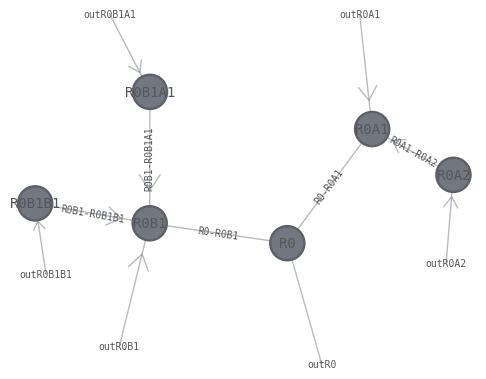

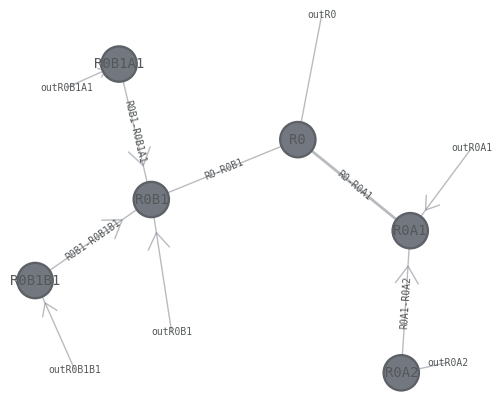

In [49]:
R0 = Node(index='R0',up = None,up_bdim = 0,childrens=['R0A1','R0B1'],childrens_bdim = [2,2])
RA1 = Node(index='R0A1',up = 'R0',up_bdim = 2,childrens=['R0A2'],childrens_bdim = [2])
RA2 = Node(index='R0A2',up = 'R0A1',up_bdim = 2,childrens=[],childrens_bdim = [])
RB1 = Node(index='R0B1',up = 'R0',up_bdim = 2,childrens=['R0B1A1','R0B1B1'],childrens_bdim = [2,2])
RB1A1 = Node(index='R0B1A1',up = 'R0B1',up_bdim = 2,childrens=[],childrens_bdim = [2])
RB1B1 = Node(index='R0B1B1',up = 'R0B1',up_bdim = 2,childrens=[],childrens_bdim = [2])

Tree1 = Tree(R0)
Tree1.add(RA1)
Tree1.add(RA2)
Tree1.add(RB1)
Tree1.add(RB1A1)
Tree1.add(RB1B1)

Tree1.network.draw(show_tags=True, show_inds='all',iterations=100, k=4)

# Tree1.swap_adjacent('R0A1','R0A2')
Tree1.swap('R0A2','R0')
# Tree1.shift_neutral('R0A1','R0A2',side = 'left')
Tree1.network.draw(show_tags=True, show_inds='all',iterations=100, k=4)

In [320]:
def to_str(node):
    return ''.join(node)

def to_list(node):
    return re.findall(r'[A-Za-z]|\d+', node)

def diff_part_str(A,B):
    A = to_list(A)
    B = to_list(B)

    prefix = []

    for i in range(min(len(A),len(B))):
        if A[i] == B[i]:
            prefix.append(A[i])
        else:
            break

    if not(prefix[-1].isnumeric()):
        prefix.pop()
    return prefix,A[len(prefix):],B[len(prefix):]

print('-------- Test diff_part_str ------')
A = 'R0A2B1'
B = 'R0A2B3'
print(A,B)
print(diff_part_str(A,B))


print('----------- Test get previous node')

def get_previous_node(node):
    nb = int(node[-1])
    if nb == 1:
        return node[0:-2]
    else:
        return node[0:-1]+[str(nb-1)]

A = to_list('R0A1B5')
print(A)
print(get_previous_node(A))

print('------------ Test path to lcn -------------')

def get_path_to_last_common_node(node,last_common_node):

    # print('getting path from ',node,' to ',last_common_node)

    path = []
    
    previous_node = node
    while previous_node != last_common_node:
        # print(' looping ', previous_node,last_common_node)
        path.append(to_str(previous_node))
        previous_node = get_previous_node(previous_node)

    path.append(to_str(last_common_node))
    return path

node = to_list('R0A3B5')
last_common_node = to_list('R0')
print(node,last_common_node)
print(get_path_to_last_common_node(node,last_common_node))

print('-')

node = to_list('R0A3')
last_common_node = to_list('R0A3')
print(node,last_common_node)
print(get_path_to_last_common_node(node,last_common_node))

-------- Test diff_part_str ------
R0A2B1 R0A2B3
(['R', '0', 'A', '2'], ['B', '1'], ['B', '3'])
----------- Test get previous node
['R', '0', 'A', '1', 'B', '5']
['R', '0', 'A', '1', 'B', '4']
------------ Test path to lcn -------------
['R', '0', 'A', '3', 'B', '5'] ['R', '0']
['R0A3B5', 'R0A3B4', 'R0A3B3', 'R0A3B2', 'R0A3B1', 'R0A3', 'R0A2', 'R0A1', 'R0']
-
['R', '0', 'A', '3'] ['R', '0', 'A', '3']
['R0A3']


In [322]:
def get_path(A,B):
    last_common_node,tail_A,tail_B = diff_part_str(A,B)

    print(last_common_node,tail_A,tail_B)


    A_to_lcn = list(reversed(get_path_to_last_common_node(to_list(A),last_common_node)))
    B_to_lcn = list(reversed(get_path_to_last_common_node(to_list(B),last_common_node)))

    print(A_to_lcn)
    print(B_to_lcn)

    for i in range(min(len(A_to_lcn),len(B_to_lcn))):
        if A_to_lcn[i] != B_to_lcn[i]:
            return list(reversed(A_to_lcn[i-1:]))+B_to_lcn[i:]
    return list(reversed(A_to_lcn[i+1:]))+B_to_lcn[i:]

get_path('R0A2B4','R0A2B5')

['R', '0', 'A', '2'] ['B', '4'] ['B', '5']
['R0A2', 'R0A2B1', 'R0A2B2', 'R0A2B3', 'R0A2B4']
['R0A2', 'R0A2B1', 'R0A2B2', 'R0A2B3', 'R0A2B4', 'R0A2B5']


['R0A2B4', 'R0A2B5']

In [ ]:
A = 'R0A2B7'
B = 'R0A2C2'


last_common_node,tail_A,tail_B = diff_part_str(A,B)

print(last_common_node,tail_A,tail_B)

A = list(reversed(get_path_to_last_common_node(to_list(A),last_common_node)))
B = list(reversed(get_path_to_last_common_node(to_list(B),last_common_node)))

print(A)
print(B)

def test(A,B):
    for i in range(min(len(A),len(B))):
        if A[i] != B[i]:
            print(i)
            return list(reversed(A[i-1:]))+B[i:]
    return list(reversed(A[i+1:]))+B[i:]
print(test(A,B))


# print(list(reversed(A[i-1:]))+B[i:])



['R', '0', 'A', '2'] ['B', '7'] ['C', '2']
['R0A2', 'R0A2B1', 'R0A2B2', 'R0A2B3', 'R0A2B4', 'R0A2B5', 'R0A2B6', 'R0A2B7']
['R0A2', 'R0A2C1', 'R0A2C2']
1
['R0A2B7', 'R0A2B6', 'R0A2B5', 'R0A2B4', 'R0A2B3', 'R0A2B2', 'R0A2B1', 'R0A2', 'R0A2C1', 'R0A2C2']


In [276]:
L = [1,2,3,4,5,6,7]
Lr = list(reversed(L))
i = 0
print(L[:-i])
print(list(reversed(Lr[i:])))

[]
[1, 2, 3, 4, 5, 6, 7]


In [ ]:
def diff_part_str_old(A,B):
    prefix = ''
    i = 0
    while i < len(A) and i < len(B) and A[i] == B[i]:
        prefix += A[i]
        i += 1
    tail_A = A[i:]
    tail_B = B[i:]
    return prefix, tail_A,tail_B
    
#diff_part_str('RA1A33','RA1A4')

def get_path(A,B):
    prefix, tail_A,tail_B = diff_part_str(A,B)
    print(prefix,type(prefix))
    print(tail_A,tail_B)
    # differents cas
        # Même branche, sans embranchement entre les deux
    if len(tail_A) == len(tail_B) == 1:
        ind_A = int(tail_A[0])
        ind_B = int(tail_B[0])
        if np.abs(ind_A-ind_B) == 1:
            if ind_A > ind_B:
                path =  [A,B]
            else:
                path =  [B,A]
        else:
            if ind_A > ind_B:
                path =  [''.join(prefix + [str(i)]) for i in range(ind_B,ind_A)]
                path.append(A)
                path.reverse()
            else:
                path =  [''.join(prefix + [str(i)]) for i in range(ind_A,ind_B)]
                path.append(B)
                path.reverse()
                pass
        return path

        
        # Même branche, avec embranchement entre les deux
        # Pas même branche, il faut monter puis redescendre

get_path('RA1B3','RA1B11')


['R', 'A', '1', 'B'] <class 'list'>
['3'] ['11']


['RA1B11',
 'RA1B10',
 'RA1B9',
 'RA1B8',
 'RA1B7',
 'RA1B6',
 'RA1B5',
 'RA1B4',
 'RA1B3']

In [5]:
prefix,tail_A,tail_B = diff_part_str('RA1B1','RA1')

print(len(tail_A),len(tail_B))
def swap_adj(tail_A,tail_B):
    if len(tail_A) == len(tail_B) == 1:# Both in branch = same lenght = 1
        if np.abs(int(tail_A) - int(tail_B)) == 1:#check if adjecentw<
            return
    elif len(tail_A) == 0 and len(tail_B) == 2 and tail_B[-1] == '1':#at crossing = not same lenght, on is zero
        return
    elif len(tail_B) == 0 and len(tail_A) == 2 and tail_A[-1] == '1':#at crossing = not same lenght, on is zero
        return
    raise Exception("not adjacent | smthg went wrong")  

swap_adj(tail_A,tail_B)

2 0


In [14]:
def swap_adjacent(tree,i,j):
    Ti = tree.network[i]
    Tj = tree.network[j]

    ind_i = Ti.inds
    ind_j = Tj.inds
    _, unshared = Ti.filter_bonds(Tj)

    ind_i_l = [i for i in unshared if i != ind_i] + [ind_j]
    print('ind_i ',ind_i)
    print('ind_j ',ind_j)
    print('ind_i_l ',ind_i_l)
    Tij = Ti @ Tj
    sTi, sTj = Tij.split(ind_i_l)

    sTi.reindex_({ind_j: ind_i}).transpose_like_(Ti)
    Ti.modify(data=sTi.data)
    sTj.reindex_({ind_i: ind_j}).transpose_like_(Tj)
    Tj.modify(data=sTj.data)

swap_adjacent(Tree1,'RB1','RB1A1')

ind_i  ('outRB1', 'Root-RB1', 'RB1-RB1A1', 'RB1-RB1B1')
ind_j  ('outRB1A1', 'RB1-RB1A1')
ind_i_l  ['outRB1', 'Root-RB1', 'RB1-RB1B1', ('outRB1A1', 'RB1-RB1A1')]


ValueError: 'output_inds' must be permutation of the current tensor indices, but {'outRB1A1', 'RB1-RB1B1', 'outRB1', 'Root-RB1'} != {'Root-RB1', 'outRB1', ('outRB1A1', 'RB1-RB1A1'), 'outRB1A1', 'RB1-RB1B1'}